## Example 4.3: The Gambler’s Problem

The gambler wants to maximize the probability of reaching **\$100** before losing everything and reaching **\$0**. If the gambler’s current capital is $s$, a legal stake is an integer from $1$ to $\min(s,100-s)$. The coin lands heads with probability $p_h=0.4$.

The textbook example shows value estimates after sweeps **1, 2, 3, and 32** of value iteration, followed by a final stake policy.

The value-iteration update is

$$
V(s)\leftarrow
\max_a\left[0.4V(s+a)+0.6V(s-a)\right],
$$

with boundary values $V(0)=0$ and $V(100)=1$. Thus, $V(s)$ is the probability of eventually reaching \$100 when the gambler follows an optimal policy.

In the resulting policy, the gambler stakes **\$50 at capital \$50**, giving a $0.4$ chance of reaching the goal on that flip. At capital \$51, the plotted policy stakes **\$1**. Multiple stakes can be equally optimal; the code selects the smallest stake when there is a tie.

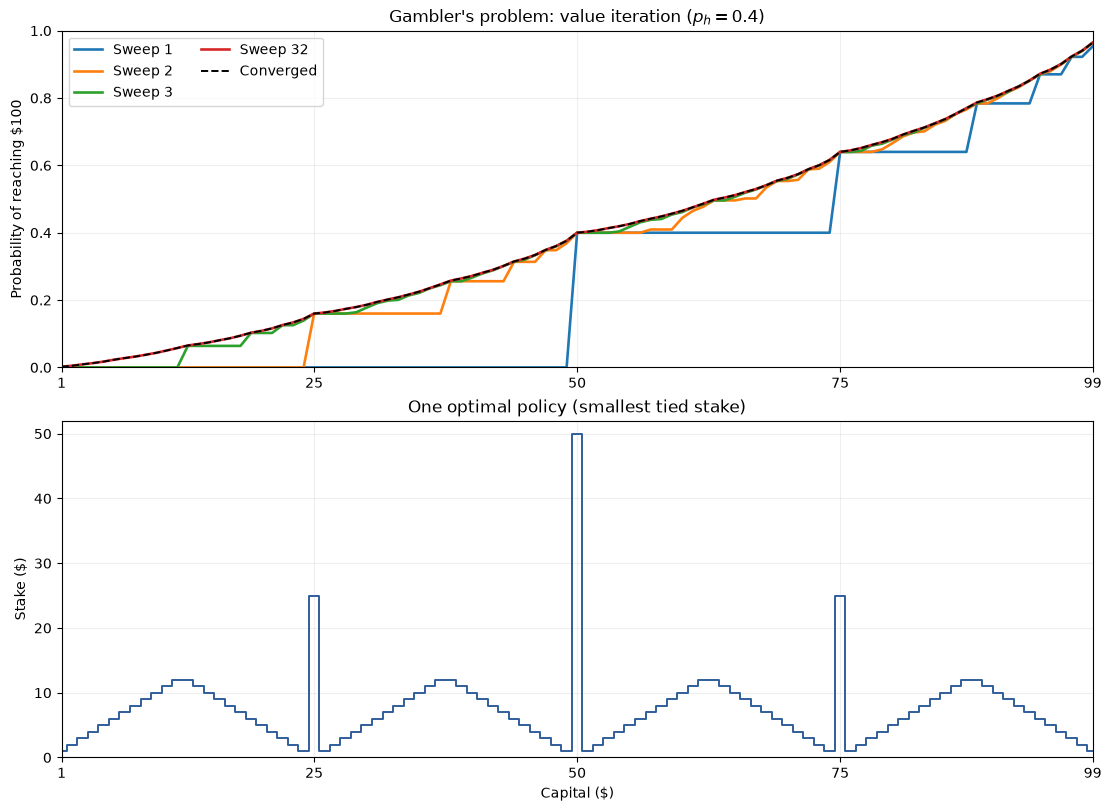

Converged after 32 sweeps (threshold 1e-12).
Capital $25: V = 0.160000, stake = $25
Capital $50: V = 0.400000, stake = $50
Capital $51: V = 0.403098, stake = $1
Capital $75: V = 0.640000, stake = $25


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

GOAL = 100
P_HEADS = 0.4
THETA = 1e-12
SHOWN_SWEEPS = (1, 2, 3, 32)


def legal_stakes(capital):
    """
    Positive integer stakes that cannot take capital below 0 or above 100.
    """
    
    return np.arange(1, min(capital, GOAL - capital) + 1)


def action_values(capital, values):
    stakes = legal_stakes(capital)
    return (P_HEADS * values[capital + stakes] + (1 - P_HEADS) * values[capital - stakes])


def value_iteration():
    # V(100)=1 encodes the sole +1 reward for reaching the goal. Because the game then ends, never update either boundary or add a second reward.
    values = np.zeros(GOAL + 1)
    values[GOAL] = 1.0
    snapshots = {}

    for sweep in range(1, 10000):
        delta = 0.0
        for capital in range(1, GOAL):
            old_value = values[capital]
            # In-place updates, proceeding from capital 1 to 99.
            values[capital] = np.max(action_values(capital, values))
            delta = max(delta, abs(old_value - values[capital]))
        if sweep in SHOWN_SWEEPS:
            snapshots[sweep] = values.copy()
        if sweep >= max(SHOWN_SWEEPS) and delta < THETA:
            break
    else:
        raise RuntimeError("Value iteration did not converge")

    policy = np.zeros(GOAL + 1, dtype=int)
    for capital in range(1, GOAL):
        stakes = legal_stakes(capital)
        q = action_values(capital, values)
        # Many stakes tie for optimality. Prefer the smallest tied stake.
        tied = np.isclose(q, q.max(), rtol=0, atol=1e-10)
        policy[capital] = stakes[np.flatnonzero(tied)[0]]

    return values, policy, snapshots, sweep

def plot_solution(values, policy, snapshots):
    capital = np.arange(1, GOAL)
    fig, (ax_value, ax_policy) = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)

    for sweep in SHOWN_SWEEPS:
        ax_value.plot(capital, snapshots[sweep][1:GOAL], label=f"Sweep {sweep}", linewidth=1.9)
    ax_value.plot(capital, values[1:GOAL], color="black", linestyle="--", linewidth=1.4, label="Converged")
    ax_value.set(title="Gambler's problem: value iteration ($p_h = 0.4$)", ylabel="Probability of reaching $100")
    ax_value.set_xlim(1, 99)
    ax_value.set_ylim(0, 1)
    ax_value.set_xticks([1, 25, 50, 75, 99])
    ax_value.grid(alpha=.2)
    ax_value.legend(loc="upper left", ncol=2)
    ax_policy.step(capital, policy[1:GOAL], where="mid", color="#305e9b", linewidth=1.4)
    ax_policy.set(xlabel="Capital ($)", ylabel="Stake ($)", title="One optimal policy (smallest tied stake)")
    ax_policy.set_xlim(1, 99)
    ax_policy.set_ylim(0, 52)
    ax_policy.set_xticks([1, 25, 50, 75, 99])
    ax_policy.set_yticks([0, 10, 20, 30, 40, 50])
    ax_policy.grid(alpha=.2)
    plt.show()

def main():
    values, policy, snapshots, sweeps = value_iteration()
    plot_solution(values, policy, snapshots)
    print(f"Converged after {sweeps} sweeps (threshold {THETA:g}).")
    for capital in (25, 50, 51, 75):
        print(f"Capital ${capital}: V = {values[capital]:.6f}, "
              f"stake = ${policy[capital]}")
    return values, policy, snapshots

if __name__ == "__main__":
    values, policy, snapshots = main()
